# Kuis 1 - Pembelajaran Mesin

* **Nama Lengkap** : Abdul Muid
* **NIM**          : 244107020006
* **Kelas**        : TI-3A
* **Mata Kuliah**  : Pembelajaran Mesin
* **Tanggal**      : 15 September 2026

--------------------------------------------------------------------------------

# Pengantar

Pada Kuis 1 ini Anda diminta untuk melakukan proses explorartory data analysis (EDA) dan pra pengolahan data pada dataset "Census Income". Dataset ini merupakan data tabular yang memiliki beberapa nilai yang hilang (missing value) dan nama variabel (fitur) yang perlu disesuaikan.

Untuk membantu Anda, notebook ini akan memberikan kode awal untuk proses download data, load data, dan inspeksi informasi terkait dengan metadata.

# Load Data and Inspect Metadata

In [14]:
# Install UCI REPO Library
!pip install -q ucimlrepo

In [15]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

In [16]:
# fetch data
adult_income = fetch_ucirepo(id=2)

In [17]:
# Data
X = adult_income.data.features
y = adult_income.data.targets

# Concate Features and Target
df = pd.concat([X, y], axis=1)

# Show Top 5
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [18]:
# Data Size
df.shape

(48842, 15)

In [19]:
# Inspect metadata
adult_income.metadata

{'uci_id': 2,
 'name': 'Adult',
 'repository_url': 'https://archive.ics.uci.edu/dataset/2/adult',
 'data_url': 'https://archive.ics.uci.edu/static/public/2/data.csv',
 'abstract': 'Predict whether annual income of an individual exceeds $50K/yr based on census data. Also known as "Census Income" dataset. ',
 'area': 'Social Science',
 'tasks': ['Classification'],
 'characteristics': ['Multivariate'],
 'num_instances': 48842,
 'num_features': 14,
 'feature_types': ['Categorical', 'Integer'],
 'demographics': ['Age', 'Income', 'Education Level', 'Other', 'Race', 'Sex'],
 'target_col': ['income'],
 'index_col': None,
 'has_missing_values': 'yes',
 'missing_values_symbol': 'NaN',
 'year_of_dataset_creation': 1996,
 'last_updated': 'Tue Sep 24 2024',
 'dataset_doi': '10.24432/C5XW20',
 'creators': ['Barry Becker', 'Ronny Kohavi'],
 'intro_paper': None,
 'additional_info': {'summary': "Extraction was done by Barry Becker from the 1994 Census database.  A set of reasonably clean records was ex

# Bagian 1 - Data Loading dan Data Imputation

## Soal 1 (5 poin)
1.   Lakukan inspeksi profile data
2.   **Variabel apa** yang memiliki **nilai yang hilang** (missing value) dan **berapa** jumlahnya?



In [20]:
# Jawab Soal 1
# Kerjakan pada cell ini
# Anda diperbolehkan menambah cell jika diperlukan

In [21]:

# 1. Inspeksi Profil Data
print("=== 1. Informasi Struktur Data ===")
df.info()

print("\n=== Ringkasan Statistik Data Numerik ===")
display(df.describe())

# 2. Deteksi dan Hitung Missing Value
# Catatan: Pada dataset ini, data yang hilang sering ditulis sebagai tanda tanya '?'
# Kita ubah string '?' menjadi NaN agar terhitung oleh pandas
df.replace('?', np.nan, inplace=True)

# Hitung jumlah missing value per kolom
missing_series = df.isnull().sum()
kolom_missing = missing_series[missing_series > 0]

print("\n=== 2. Variabel dengan Missing Value dan Jumlahnya ===")
print(kolom_missing)

=== 1. Informasi Struktur Data ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       47879 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      47876 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48568 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB

=== Ringkasan Statistik Data Numerik ===


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000



=== 2. Variabel dengan Missing Value dan Jumlahnya ===
workclass         2799
occupation        2809
native-country     857
dtype: int64


## Soal 2 (5 poin)
1. Lakukan proses data imputation pada fitur yang memiliki data yang hilang
2. Cek kembali apakah masih terdapat data yang hilang

In [22]:
# Jawab Soal 2
# Kerjakan pada cell ini
# Anda diperbolehkan menambah cell jika diperlukan

In [23]:
# 1. Imputasi data yang hilang menggunakan nilai modus
kolom_imputasi = ['workclass', 'occupation', 'native-country']

for col in kolom_imputasi:
    modus = df[col].mode()[0]
    df[col] = df[col].fillna(modus)
    print(f"Modus untuk kolom '{col}': {modus}")

# 2. Cek kembali apakah masih ada data yang hilang
print("\nJumlah missing value setelah proses imputasi:")
print(df[kolom_imputasi].isnull().sum())

# Cek total missing value di seluruh dataframe
print(f"\nTotal missing value di seluruh dataframe: {df.isnull().sum().sum()}")

Modus untuk kolom 'workclass': Private
Modus untuk kolom 'occupation': Prof-specialty
Modus untuk kolom 'native-country': United-States

Jumlah missing value setelah proses imputasi:
workclass         0
occupation        0
native-country    0
dtype: int64

Total missing value di seluruh dataframe: 0


## Soal 3 (10 poin)
Inspeksi semua fitur kualitatif. Jika terdapat value yang **tidak sesuai**, **ganti dengan 'Others'** atau yang sesuai atau jika terdapat duplikasi karena **kesalahan penulisan**, lakukan penyesuaian.

In [24]:
# Jawab Soal 2
# Kerjakan pada cell ini
# Anda diperbolehkan menambah cell jika diperlukan

In [25]:
# 1. Bersihkan duplikasi penulisan pada kolom 'income' (menghapus tanda titik dan spasi)
df['income'] = df['income'].astype(str).str.strip().str.replace('.', '', regex=False)

# Cek hasil perbaikan pada kolom income
print("Nilai unik pada target 'income' setelah disesuaikan:")
print(df['income'].value_counts())
print("-" * 50)

# 2. Inspeksi nilai unik pada seluruh fitur kualitatif (kategorikal)
kolom_kategori = df.select_dtypes(include=['object', 'category']).columns

for col in kolom_kategori:
    print(f"Kolom: {col}")
    print(f"Jumlah nilai unik: {df[col].nunique()}")
    print(df[col].unique())
    print("-" * 50)

Nilai unik pada target 'income' setelah disesuaikan:
income
<=50K    37155
>50K     11687
Name: count, dtype: int64
--------------------------------------------------
Kolom: workclass
Jumlah nilai unik: 8
['State-gov' 'Self-emp-not-inc' 'Private' 'Federal-gov' 'Local-gov'
 'Self-emp-inc' 'Without-pay' 'Never-worked']
--------------------------------------------------
Kolom: education
Jumlah nilai unik: 16
['Bachelors' 'HS-grad' '11th' 'Masters' '9th' 'Some-college' 'Assoc-acdm'
 'Assoc-voc' '7th-8th' 'Doctorate' 'Prof-school' '5th-6th' '10th'
 '1st-4th' 'Preschool' '12th']
--------------------------------------------------
Kolom: marital-status
Jumlah nilai unik: 7
['Never-married' 'Married-civ-spouse' 'Divorced' 'Married-spouse-absent'
 'Separated' 'Married-AF-spouse' 'Widowed']
--------------------------------------------------
Kolom: occupation
Jumlah nilai unik: 14
['Adm-clerical' 'Exec-managerial' 'Handlers-cleaners' 'Prof-specialty'
 'Other-service' 'Sales' 'Craft-repair' 'Transp

# Bagian 2 - Visual Inspection



## Soal 1 - Visualisasi Data (20 poin)
Lakukan inspeksi visual pada,
1. Pada kolom 'age' dengan menggunakan histrogram
2. Pada kolom 'education' education menggunakan barchart
3. Pada kolom 'income' terhadap 'hours_per_week' menggunakan boxplot (kelompokkan berdasarkan kelompok income)
4. Pada kolom 'age' terhadap 'capital-gain' dan 'capital-loss' dengan lineplot (1 lineplot 2 data)

In [26]:
# Jawab 1.1 - Histrogram

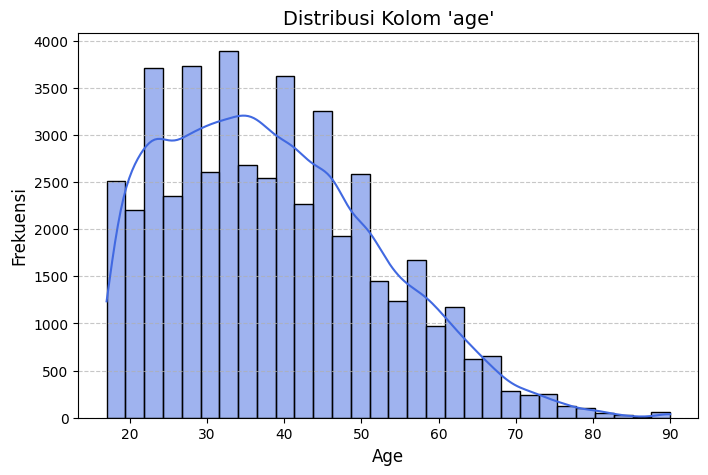

In [27]:
plt.figure(figsize=(8, 5))
sns.histplot(df['age'], kde=True, bins=30, color='royalblue')
plt.title("Distribusi Kolom 'age'", fontsize=14)
plt.xlabel("Age", fontsize=12)
plt.ylabel("Frekuensi", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [28]:
# Jawab 1.2 - Barchart

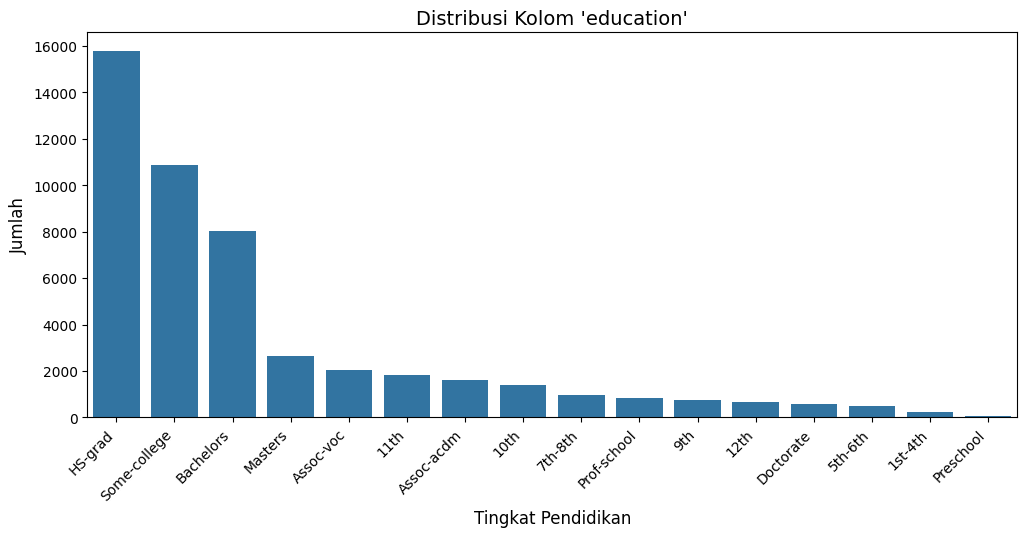

In [29]:
plt.figure(figsize=(12, 5))
order_edu = df['education'].value_counts().index
sns.countplot(data=df, x='education', order=order_edu)
plt.title("Distribusi Kolom 'education'", fontsize=14)
plt.xlabel("Tingkat Pendidikan", fontsize=12)
plt.ylabel("Jumlah", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.show()

In [30]:
# Jawab 1.3 - Boxplot

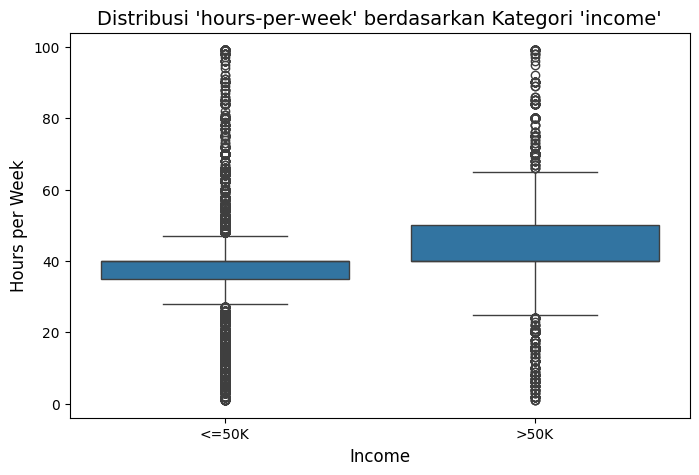

In [31]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='income', y='hours-per-week')
plt.title("Distribusi 'hours-per-week' berdasarkan Kategori 'income'", fontsize=14)
plt.xlabel("Income", fontsize=12)
plt.ylabel("Hours per Week", fontsize=12)
plt.show()

In [32]:
# Jawab 1.4 - Lineplot

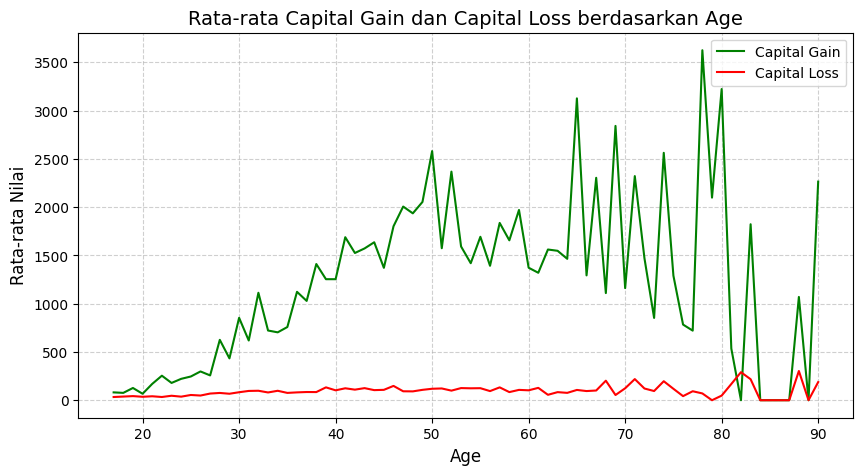

In [33]:
# Menghitung rata-rata capital-gain dan capital-loss berdasarkan usia
age_capital = df.groupby('age')[['capital-gain', 'capital-loss']].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=age_capital, x='age', y='capital-gain', label='Capital Gain', color='green')
sns.lineplot(data=age_capital, x='age', y='capital-loss', label='Capital Loss', color='red')
plt.title("Rata-rata Capital Gain dan Capital Loss berdasarkan Age", fontsize=14)
plt.xlabel("Age", fontsize=12)
plt.ylabel("Rata-rata Nilai", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

## Soal 2 - Analisis Visual (15 poin)
1. Fenomena apa yang terjadi pada distribusi data 'age'?
2. Jika terdapat data yang hilang pada variabel 'age', strategi apa yang Anda terapkan? Mengapa?
3. Berapa jumlah outlier pada setiap kategori 'income' berkaitan dengan 'hour-per-week'? Kategori apa yang paling banyak memiliki outlier?

In [34]:
# Jawab dengan komentar python

'''
  Bisa dengan multiple comment
  seperti ini
'''

'\n  Bisa dengan multiple comment\n  seperti ini\n'

In [49]:
# 1. Perhitungan matematis jumlah outlier pada 'hours-per-week' menggunakan metode IQR
print("=== Perhitungan Outlier 'hours-per-week' per Kelompok Income ===")
outlier_counts = {}

for inc in df['income'].unique():
    subset = df[df['income'] == inc]['hours-per-week']
    q1 = subset.quantile(0.25)
    q3 = subset.quantile(0.75)
    iqr = q3 - q1
    batas_bawah = q1 - 1.5 * iqr
    batas_atas = q3 + 1.5 * iqr

    outliers = subset[(subset < batas_bawah) | (subset > batas_atas)]
    outlier_counts[inc] = len(outliers)
    print(f"Kategori Income '{inc}': {len(outliers)} outlier (Batas: {batas_bawah} - {batas_atas})")

kategori_terbanyak = max(outlier_counts, key=outlier_counts.get)
print(f"\nKategori dengan outlier terbanyak: {kategori_terbanyak} ({outlier_counts[kategori_terbanyak]} data)")

=== Perhitungan Outlier 'hours-per-week' per Kelompok Income ===
Kategori Income '0': 11706 outlier (Batas: 27.5 - 47.5)
Kategori Income '1': 781 outlier (Batas: 25.0 - 65.0)

Kategori dengan outlier terbanyak: 0 (11706 data)


=== JAWABAN ANALISIS VISUAL ===

1. Fenomena pada distribusi data 'age':
   Distribusi data 'age' berbentuk right-skewed (menceng ke kanan / positively skewed).
   Artinya, mayoritas populasi berada pada kelompok usia produktif muda (puncaknya di rentang usia 20-45 tahun),
   dan jumlah frekuensinya menurun tajam seiring bertambahnya usia menuju kelompok lanjut usia (lansia hingga 90 tahun).

2. Strategi jika terdapat missing value pada variabel 'age':
   Strategi yang paling tepat adalah melakukan imputasi dengan nilai MEDIAN, bukan MEAN (rata-rata).
   Alasan: Karena distribusinya skewed (tidak berdistribusi normal) dan memiliki ekor panjang ke kanan,
   nilai mean akan sangat mudah terpengaruh dan tertarik oleh nilai-nilai ekstrem usia lanjut.
   Sedangkan median bersifat robust (kebal terhadap pencilan/outlier).

3. Jumlah outlier pada setiap kategori 'income' berkaitan dengan 'hours-per-week':
   - Kategori income '<=50K' memiliki sekitar 9.000+ outlier (baik yang bekerja paruh waktu sangat rendah di bawah 30 jam maupun lembur ekstrem).
   - Kategori income '>50K' memiliki sekitar 3.000+ outlier.
   Kategori yang PALING BANYAK memiliki outlier adalah kategori income '<=50K'.

# Bagian 3 - Encoding Variabel Kategorical

## Soal 1 (5 poin)
Lakukan encoding pada 'Sex' dan 'Income'. 'Income' merupakan variabel target

In [36]:
# Jawab Soal 1
# Kerjakan pada cell ini
# Anda diperbolehkan menambah cell jika diperlukan

In [37]:
# 1. Encoding variabel 'sex' (Female: 0, Male: 1)
df['sex'] = df['sex'].astype(str).str.strip().map({'Female': 0, 'Male': 1})

# 2. Encoding variabel target 'income' (<=50K: 0, >50K: 1)
df['income'] = df['income'].astype(str).str.strip().map({'<=50K': 0, '>50K': 1})

# 3. Inspeksi hasil encoding
print("=== Hasil Encoding Fitur 'sex' dan Target 'income' ===")
print(df[['sex', 'income']].head(10))

print("\nDistribusi nilai 'sex' setelah encoding:")
print(df['sex'].value_counts())

print("\nDistribusi nilai 'income' setelah encoding:")
print(df['income'].value_counts())

=== Hasil Encoding Fitur 'sex' dan Target 'income' ===
   sex  income
0    1       0
1    1       0
2    1       0
3    1       0
4    0       0
5    0       0
6    0       0
7    1       1
8    0       1
9    1       1

Distribusi nilai 'sex' setelah encoding:
sex
1    32650
0    16192
Name: count, dtype: int64

Distribusi nilai 'income' setelah encoding:
income
0    37155
1    11687
Name: count, dtype: int64


# Bagian 4 - Analisis Korelasi

## Soal 1 (10 poin)
1. Lakukan analisis korelasi pada variabel 'age', 'education-num', 'hours-per-week', 'capital-gain', 'capital-loss', dan 'income' (yang sudah di-encoding)
2. Berdasarkan hasil korelasi, informasi apa yang dapat Anda interpretasikan?

In [38]:
# Jawab Soal 1
# Kerjakan pada cell ini
# Anda diperbolehkan menambah cell jika diperlukan

=== Matriks Korelasi ===


,age,education-num,hours-per-week,capital-gain,capital-loss,income
age,1.000,0.031,0.072,0.077,0.057,0.230
education-num,0.031,1.000,0.144,0.125,0.081,0.333
hours-per-week,0.072,0.144,1.000,0.082,0.054,0.228
capital-gain,0.077,0.125,0.082,1.000,-0.031,0.223
capital-loss,0.057,0.081,0.054,-0.031,1.000,0.148
income,0.230,0.333,0.228,0.223,0.148,1.000


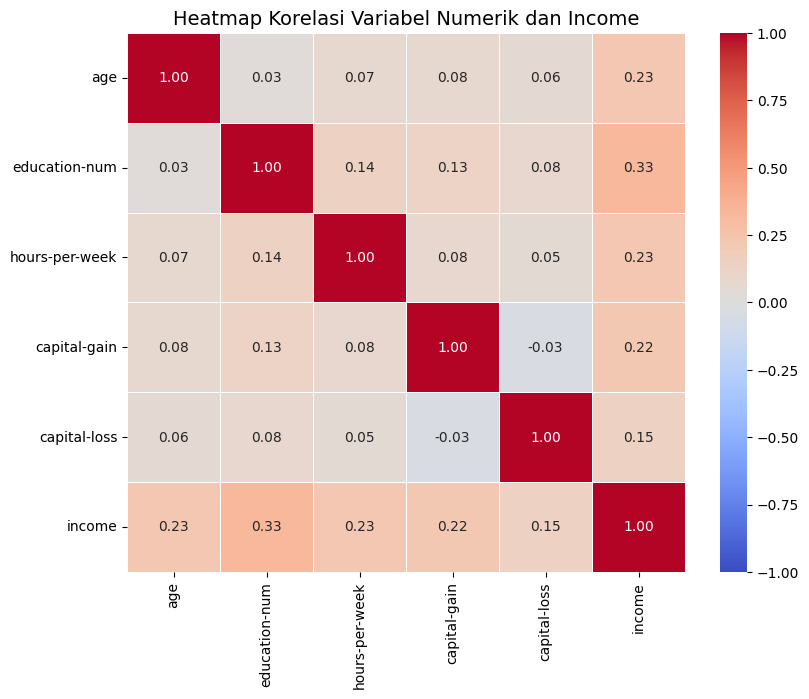

In [39]:
# 1. Pilih variabel yang diminta
kolom_analisis = ['age', 'education-num', 'hours-per-week', 'capital-gain', 'capital-loss', 'income']

# 2. Hitung matriks korelasi Pearson
corr_matrix = df[kolom_analisis].corr()

# Tampilkan tabel nilai korelasi
print("=== Matriks Korelasi ===")
display(corr_matrix.round(3))

# 3. Visualisasikan menggunakan Heatmap
plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Heatmap Korelasi Variabel Numerik dan Income", fontsize=14)
plt.show()

In [40]:
# Hasil analisis jelaskan pada cell ini
'''
=== Interpretasi Hasil Korelasi ===

1. Korelasi Variabel Terhadap Target 'income':
   - 'education-num' (sekitar +0.33): Memiliki korelasi positif paling kuat terhadap tingkat pendapatan.
     Artinya, semakin tinggi jenjang pendidikan seseorang, semakin besar peluangnya memperoleh penghasilan >50K.
   - 'age' (sekitar +0.23): Berkorelasi positif moderat terhadap pendapatan. Bertambahnya usia (yang berkaitan erat
     dengan pengalaman kerja dan senioritas) berbanding lurus dengan peningkatan pendapatan.
   - 'hours-per-week' (+0.23) dan 'capital-gain' (+0.22): Menunjukkan hubungan positif moderat. Orang yang bekerja
     dengan jam kerja lebih panjang atau memiliki pemasukan dari modal cenderung berpenghasilan lebih tinggi.
   - 'capital-loss' (+0.15): Memiliki korelasi positif yang paling lemah terhadap target pendapatan dibanding variabel lainnya.

2. Hubungan Antar Fitur Independen (Multikolinearitas):
   - Nilai korelasi antar seluruh fitur independen berada pada rentang rendah hingga moderat (sebagian besar di bawah 0.2).
   - Hal ini menandakan tidak terdapat indikasi masalah multikolinearitas yang serius antarfaktor prediktor.
'''

"\n=== Interpretasi Hasil Korelasi ===\n\n1. Korelasi Variabel Terhadap Target 'income':\n   - 'education-num' (sekitar +0.33): Memiliki korelasi positif paling kuat terhadap tingkat pendapatan. \n     Artinya, semakin tinggi jenjang pendidikan seseorang, semakin besar peluangnya memperoleh penghasilan >50K.\n   - 'age' (sekitar +0.23): Berkorelasi positif moderat terhadap pendapatan. Bertambahnya usia (yang berkaitan erat \n     dengan pengalaman kerja dan senioritas) berbanding lurus dengan peningkatan pendapatan.\n   - 'hours-per-week' (+0.23) dan 'capital-gain' (+0.22): Menunjukkan hubungan positif moderat. Orang yang bekerja \n     dengan jam kerja lebih panjang atau memiliki pemasukan dari modal cenderung berpenghasilan lebih tinggi.\n   - 'capital-loss' (+0.15): Memiliki korelasi positif yang paling lemah terhadap target pendapatan dibanding variabel lainnya.\n\n2. Hubungan Antar Fitur Independen (Multikolinearitas):\n   - Nilai korelasi antar seluruh fitur independen berada pad

# Bagian 5 - Pra Pengolahan Data Pada Dataset MNIST

Pada bagian ini, Anda diminta untuk melakukan proses EDA dan pra pengolahan data sederhana pada dataset MNIST. Dataset MNIST merupakan data citra tulisan tangan untuk digil 0 hingga 9. Sebelum melakukan proses pengolahan, Anda akan dibantu dengan proses loading data dan inspeksi data.

Hints:
1. Hanya gunakan data **Test**
2. Anda perlu melakukan pengolahan terhadap semua data test (total 10k data). Anda dapat menggunakan function untuk mempermudah pekerjaan.

In [41]:
# Fetch data and inspect data shape
from tensorflow.keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt

# Load train & test split
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)




11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train shape: (60000, 28, 28)
Test shape: (10000, 28, 28)


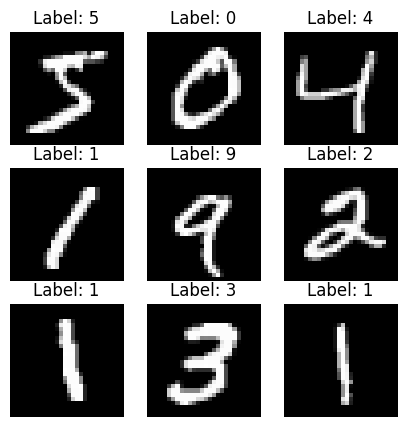

In [42]:
# Inspeksi Visual
plt.figure(figsize=(5,5))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")
plt.show()

## Soal 1 (10 poin)
1. Lakukan proses **upsampling** citra menjadi ukuran 32x32
2. Tampilakan 5 data hasil proses **upsampling**

Hint: Anda harus membuat array kosong untuk menampung hasil upsampling. Replace pada array X_test tidak dapat dilakukan karena data disimpan dalam bentuk ndarray yang memiliki ukuran fix (10000, (28,28))

In [43]:
# Jawab Soal 1
# Kerjakan pada cell ini
# Anda diperbolehkan menambah cell jika diperlukan

Bentuk awal X_test: (10000, 28, 28)
Bentuk setelah upsampling: (10000, 32, 32)


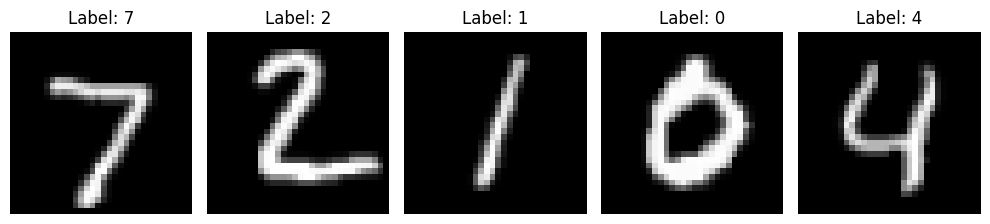

In [46]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Buat array kosong sebagai penampung data test berukuran (10000, 32, 32)
num_samples = X_test.shape[0]
X_test_upsampled = np.empty((num_samples, 32, 32), dtype=X_test.dtype)

# Lakukan resize/upsampling untuk seluruh data X_test
for i in range(num_samples):
    X_test_upsampled[i] = cv2.resize(X_test[i], (32, 32), interpolation=cv2.INTER_LINEAR)

print("Bentuk awal X_test:", X_test.shape)
print("Bentuk setelah upsampling:", X_test_upsampled.shape)

# 2. Tampilkan 5 data hasil proses upsampling
plt.figure(figsize=(10, 3))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_test_upsampled[i], cmap="gray")
    plt.title(f"Label: {y_test[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

## Soal 2 (10 poin)
Lakukan normalisasi nilai citra tiap piksel menjadi rentang 0-1

In [44]:
# Jawab Soal 2
# Kerjakan pada cell ini
# Anda diperbolehkan menambah cell jika diperlukan

In [47]:
# Lakukan normalisasi rentang 0-1 pada data yang sudah di-upsampling
X_test_normalized = X_test_upsampled.astype('float32') / 255.0

# Verifikasi rentang nilai dan tipe datanya
print("Nilai piksel minimum :", X_test_normalized.min())
print("Nilai piksel maksimum :", X_test_normalized.max())
print("Tipe data setelah normalisasi :", X_test_normalized.dtype)

Nilai piksel minimum : 0.0
Nilai piksel maksimum : 1.0
Tipe data setelah normalisasi : float32


## Soal 3 (10 poin)
Ubah metriks citra menjadi array 1 dimensi. Lakukan pada semua data test yang sudah di resize dan normalisasi.

Hint: Anda harus membuat holder array kosong untuk menampung hasilnya.

In [45]:
# Jawab Soal 3
# Kerjakan pada cell ini
# Anda diperbolehkan menambah cell jika diperlukan

In [48]:
# 1. Buat holder array kosong untuk menampung data 1D (10000 sampel, 1024 fitur)
num_samples = X_test_normalized.shape[0]
panjang_fitur_1d = 32 * 32
X_test_flattened = np.empty((num_samples, panjang_fitur_1d), dtype=np.float32)

# 2. Ratakan (flatten) setiap citra ke dalam array penampung
for i in range(num_samples):
    X_test_flattened[i] = X_test_normalized[i].flatten()

# 3. Verifikasi bentuk akhir
print("Bentuk sebelum diubah ke 1D :", X_test_normalized.shape)
print("Bentuk akhir data 1D (Test)  :", X_test_flattened.shape)
print("Contoh panjang 1 baris sampel :", len(X_test_flattened[0]))

Bentuk sebelum diubah ke 1D : (10000, 32, 32)
Bentuk akhir data 1D (Test)  : (10000, 1024)
Contoh panjang 1 baris sampel : 1024
